In [1]:
from model_ranking import load_transfer_metric_results
from model_ranking import plot_performance_vs_transfer_metric

INFO: P [MainThread] 2025-08-14 09:51:26,616 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


# Load Precomputed Results

In [2]:
NCTI_path = "/scratch/talks/sampled_features/semantic_segmentation/mitochondria/transfer_metric_results/mitochondria_NCTI.json"

NCTI_results = load_transfer_metric_results(NCTI_path)
NCTI_scores = NCTI_results["transfer_scores"]
component_scores = NCTI_results["component_transfer_scores"]
performance_scores = NCTI_results["performance_scores"]
correlation_scores = NCTI_results["correlation_scores"]

Loaded Transfer metric results from: /scratch/talks/sampled_features/semantic_segmentation/mitochondria/transfer_metric_results/mitochondria_NCTI.json
Experiment: mitochondria_NCTI
Targets: 4 (EPFL, Hmito, Rmito, VNC)
Source models: 15
Total transfers: 57


# Full NCTI score

Target: EPFL


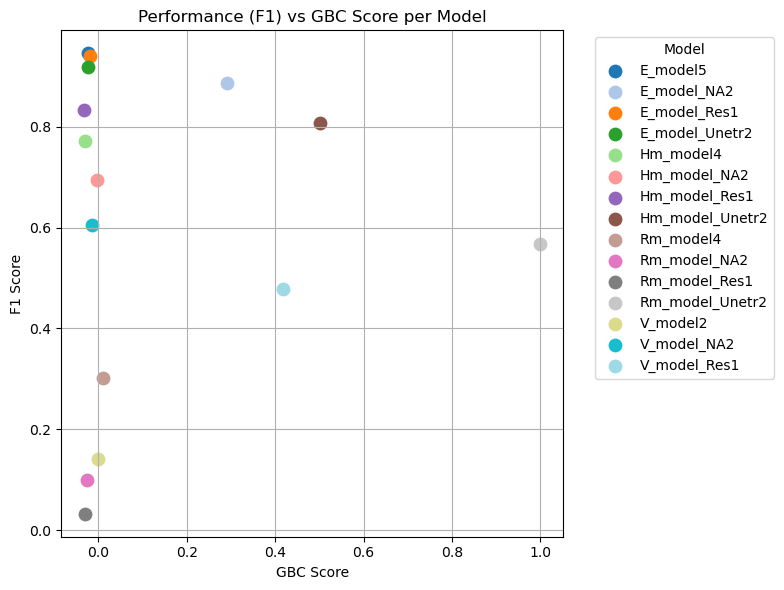

Target: Hmito


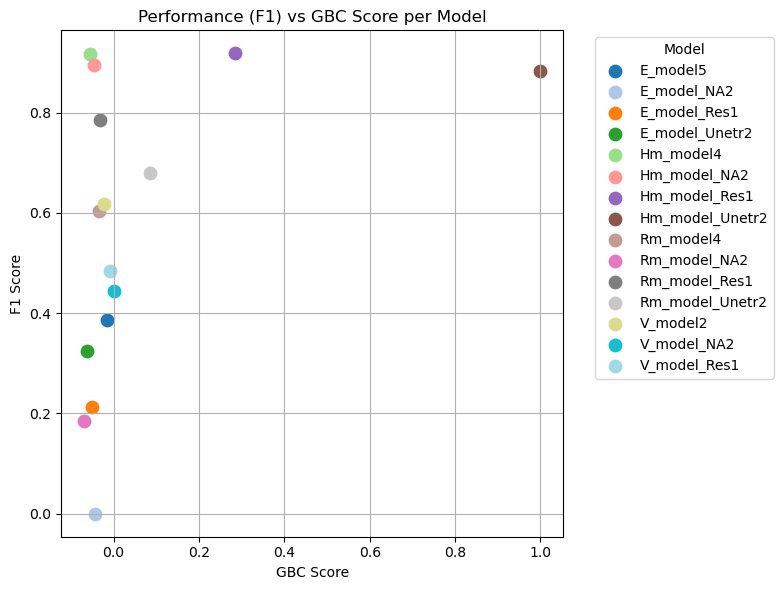

Target: Rmito


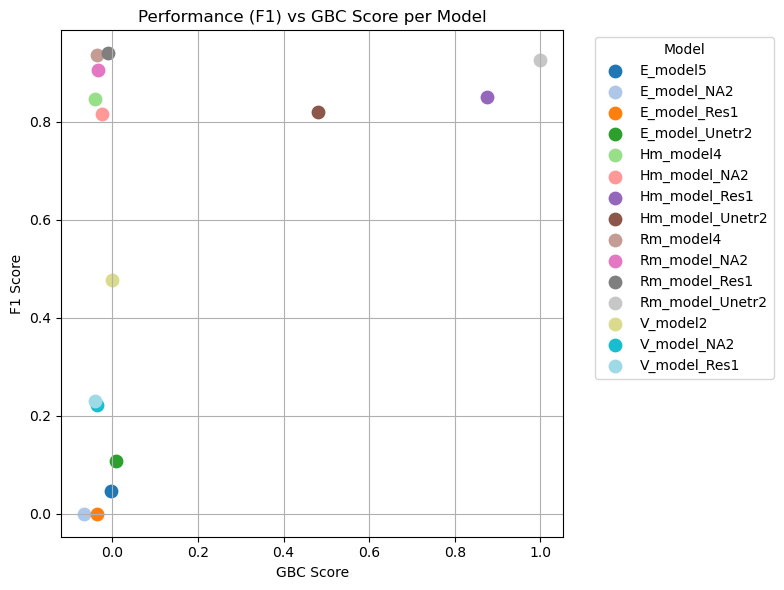

Target: VNC


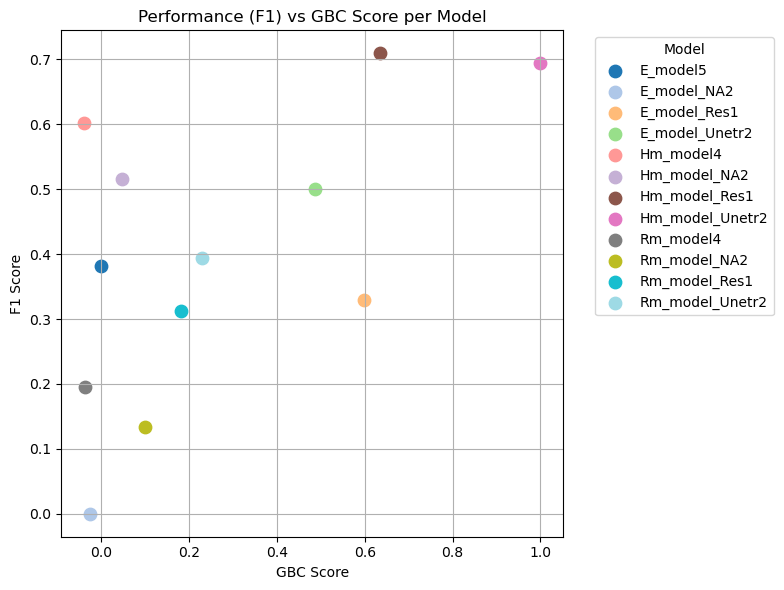

In [3]:
for target, scores_per_model in NCTI_scores.items():
    print(f"Target: {target}")
    plot_performance_vs_transfer_metric(performance_scores[target], scores_per_model)

In [6]:
import pandas as pd
import numpy as np

idx = 0
per_target_KT = np.array(correlation_scores["KT"])
per_target_SP = np.array(correlation_scores["SP"])
per_target_PE = np.array(correlation_scores["PE"])
df = pd.DataFrame(
    {
        "kt": per_target_KT[:, idx, 0], 
        "kt pval": per_target_KT[:, idx, 1], 
        "s rho": per_target_SP[:, idx, 0], 
        "s rho pval": per_target_SP[:, idx, 1], 
        "pr": per_target_PE[:, idx, 0], 
        "pr pval": per_target_PE[:, idx, 1]
    },
)
df["targets"] = NCTI_results["metadata"]["targets"]
df = df.set_index("targets")
df.index = pd.MultiIndex.from_product([["Mito"], df.index], names=["Task", "targets"])
# Round all float columns to 2 significant figures
df = df.map(lambda x: round(x, 2) if isinstance(x, float) else x)
print(df)

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.07     0.81  -0.07        0.75 -0.05     0.85
     Hmito    0.42     0.12   0.42        0.12  0.30     0.14
     Rmito    0.42     0.12   0.35        0.23  0.27     0.16
     VNC      0.58     0.05   0.44        0.17  0.33     0.13


# Partial NCTI Scores

## Simplicity to Nearest Centroid Classifier

Target: EPFL


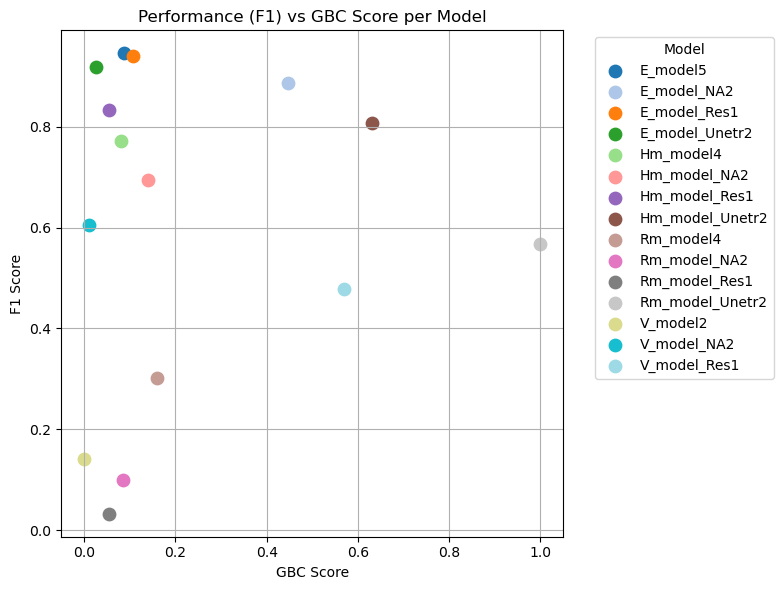

Target: Hmito


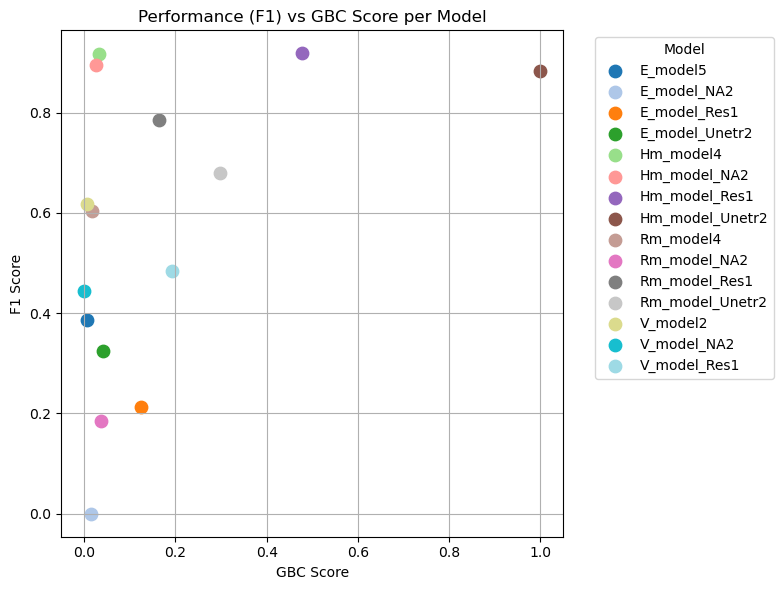

Target: Rmito


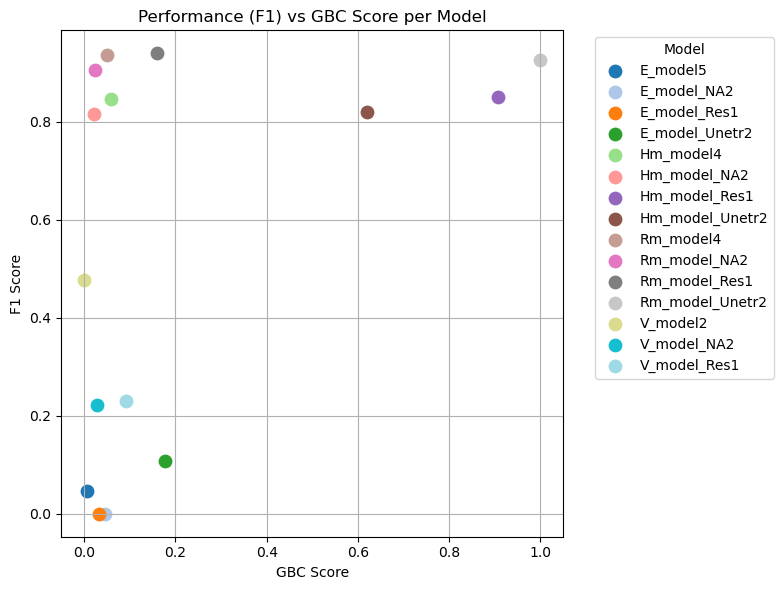

Target: VNC


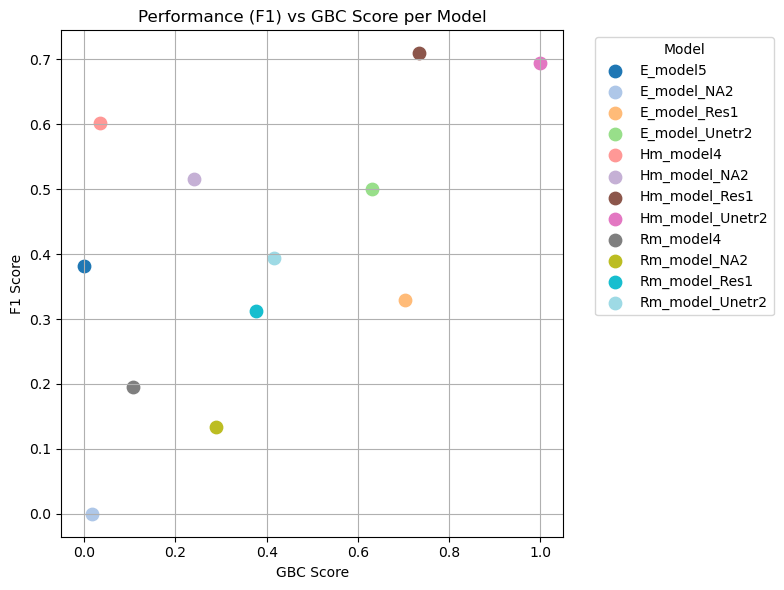

In [5]:
for target, scores_per_model in component_scores.items():
    print(f"Target: {target}")
    plot_performance_vs_transfer_metric(performance_scores[target], scores_per_model["NCC"])

## Simplex Encoded Labels Interpolation (SELI)

Target: EPFL


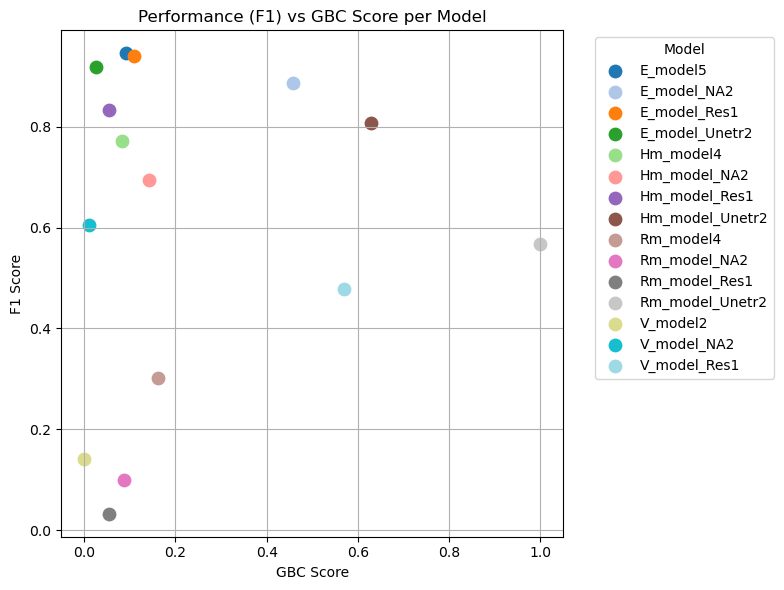

Target: Hmito


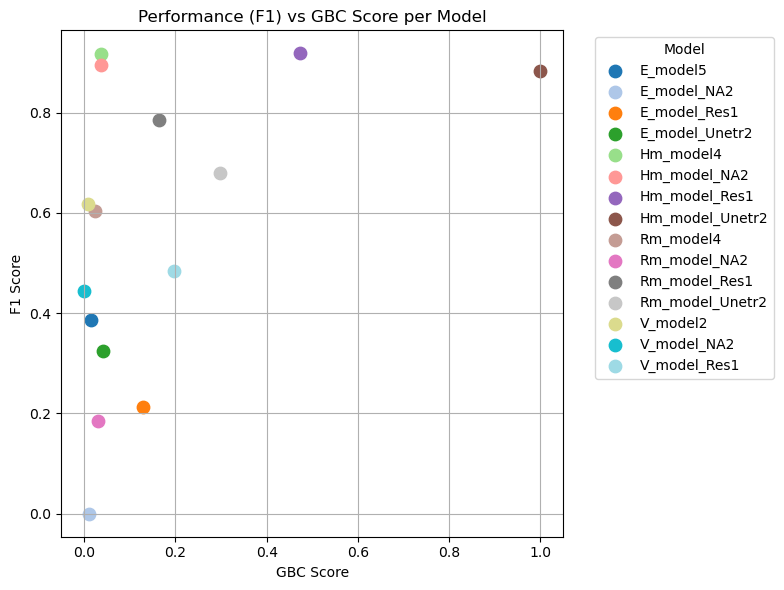

Target: Rmito


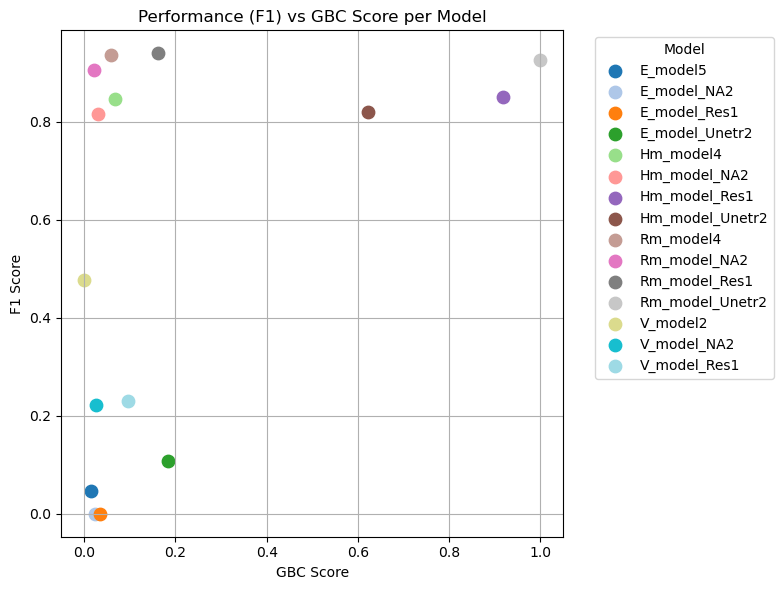

Target: VNC


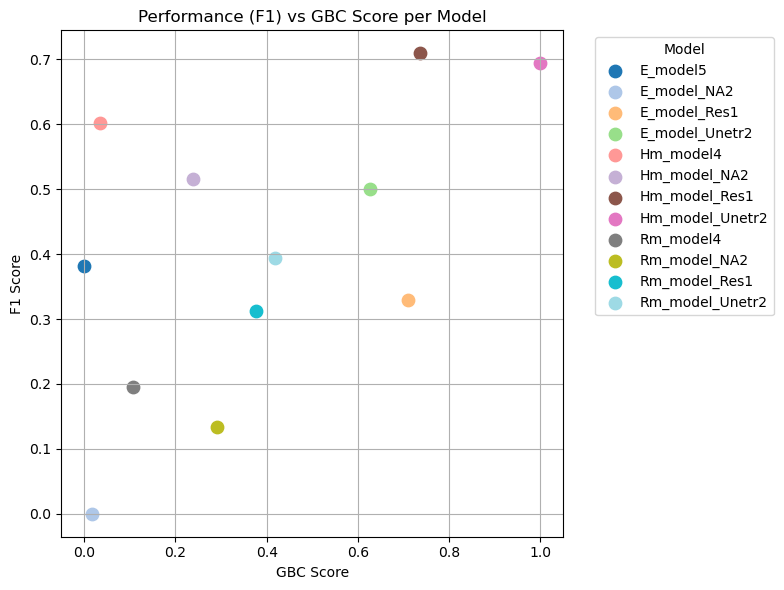

In [6]:
for target, scores_per_model in component_scores.items():
    print(f"Target: {target}")
    plot_performance_vs_transfer_metric(performance_scores[target], scores_per_model["SELI"])

## Within-class Variability Collapse

Target: EPFL


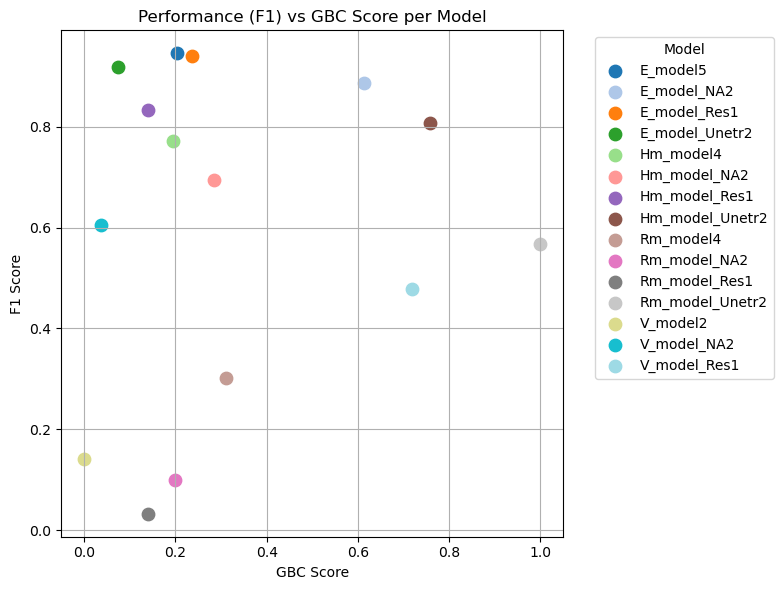

Target: Hmito


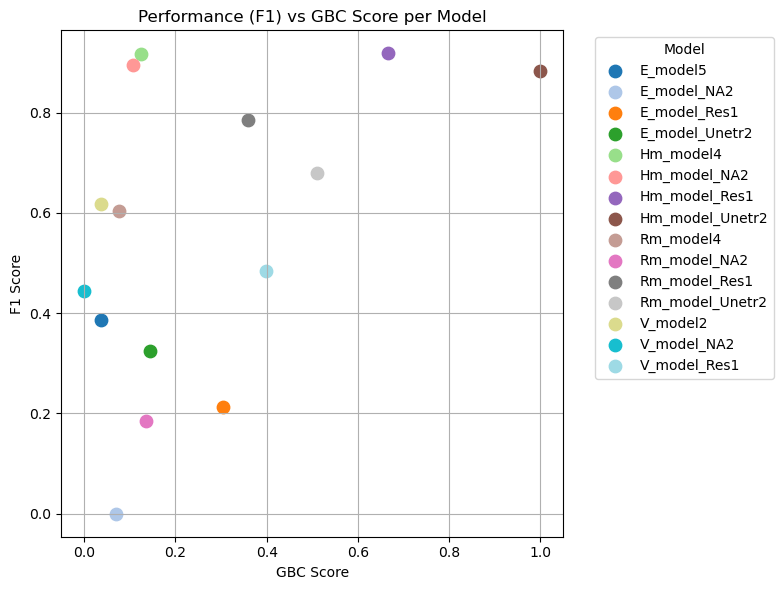

Target: Rmito


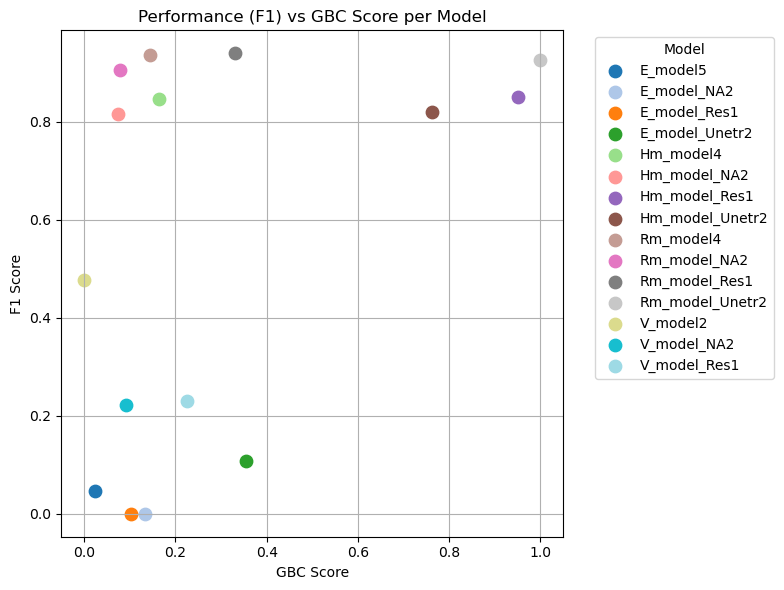

Target: VNC


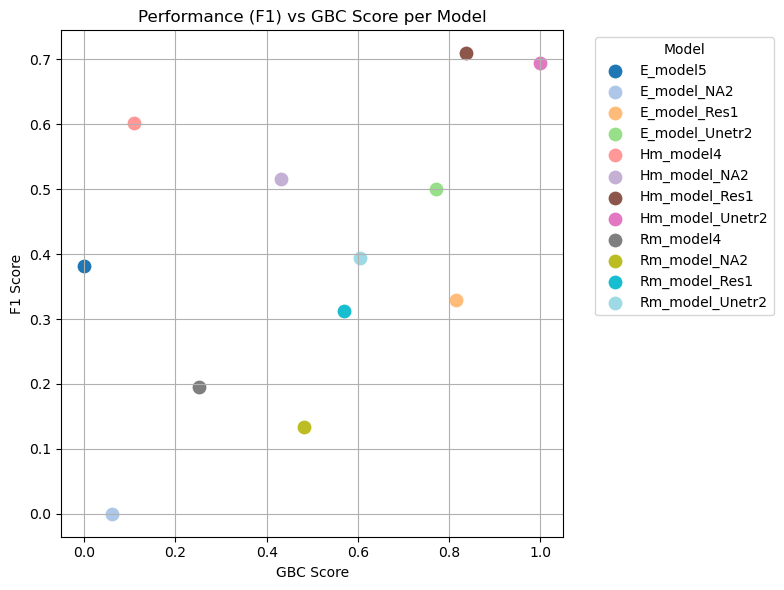

In [7]:
for target, scores_per_model in component_scores.items():
    print(f"Target: {target}")
    plot_performance_vs_transfer_metric(performance_scores[target], scores_per_model["VC"])